In [37]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:

pasta = "./outputs-tarefa"
dfs = []

In [39]:
for arquivo in os.listdir(pasta):
    if arquivo.endswith(".csv"):
        df = pd.read_csv(os.path.join(pasta, arquivo))
        df["FILE_NAME"] = arquivo
        dfs.append(df)

In [40]:
df_raw = pd.concat(dfs, ignore_index=True)

In [41]:
df_raw["nos"] = df_raw["file_name".upper()].str.extract(r"nos(\d+)").astype(int)
df_raw["cfg"] = df_raw["file_name".upper()].str.extract(r"cfg(\d+)").astype(int)
df_raw["raio"] = df_raw["file_name".upper()].str.extract(r"r(\d+)").astype(int)

In [42]:
df_raw.to_csv('atividade5.csv')

In [43]:
display(df_raw)

,nrNodes,der,nrCollisions,nrTransmissions,nrReceived,nrLost,FILE_NAME,nos,cfg,raio
0,150,0.604167,5073,12816,7743,0,exp_nos150_cfg0_r1000.csv,150,0,1000
1,150,0.410278,2650,13018,5341,5027,exp_nos150_cfg0_r10000.csv,150,0,10000
2,150,0.062333,254,12738,794,11690,exp_nos150_cfg0_r20000.csv,150,0,20000
3,150,0.598950,5193,12951,7757,0,exp_nos150_cfg0_r5000.csv,150,0,5000
4,150,0.976981,303,13163,12860,0,exp_nos150_cfg1_r1000.csv,150,1,1000
5,150,0.167866,24,13064,2193,10847,exp_nos150_cfg1_r10000.csv,150,1,10000
6,150,0.019573,1,13028,255,12772,exp_nos150_cfg1_r20000.csv,150,1,20000
7,150,0.623496,134,13049,8136,4779,exp_nos150_cfg1_r5000.csv,150,1,5000
8,150,0.979370,266,12894,12628,0,exp_nos150_cfg2_r1000.csv,150,2,1000
9,150,0.722791,143,12983,9384,3456,exp_nos150_cfg2_r10000.csv,150,2,10000


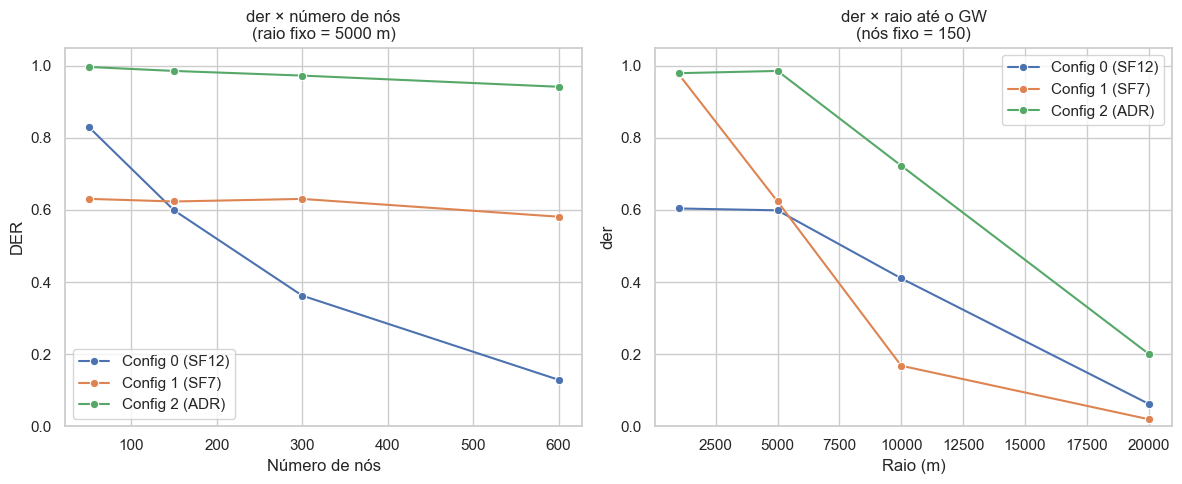

In [44]:
df = df_raw[df_raw["nrNodes"] == df_raw['nos']].copy()

cfg_labels = {0: "Config 0 (SF12)", 1: "Config 1 (SF7)", 2: "Config 2 (ADR)"}
df["cfg_label"] = df["cfg"].map(cfg_labels)

df_nos = df[df["raio"] == 5000].sort_values("nos")
df_raio = df[df["nos"] == 150].sort_values("raio")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# gráfico 1 - der x nós
sns.lineplot(data=df_nos, x="nos", y=" der", hue="cfg_label", marker="o", ax=axes[0])
axes[0].set_title("der × número de nós\n(raio fixo = 5000 m)")
axes[0].set_xlabel("Número de nós")
axes[0].set_ylabel("DER")
axes[0].set_ylim(0, 1.05)
axes[0].legend(title=None)

# gráfico 2 - der x raio
sns.lineplot(data=df_raio, x='raio', y=" der", hue="cfg_label", marker="o", ax=axes[1])
axes[1].set_title("der × raio até o GW\n(nós fixo = 150)")
axes[1].set_xlabel("Raio (m)")
axes[1].set_ylabel('der')
axes[1].set_ylim(0, 1.05)
axes[1].legend(title=None)

plt.tight_layout()
plt.savefig("der_analise.png", dpi=150)
plt.show()